In [67]:
import sys
!{sys.executable} -m pip install openpyxl

'c:\Users\Atharv' is not recognized as an internal or external command,
operable program or batch file.


In [68]:
import sys
print(sys.executable)

c:\Users\Atharv Bansal\Desktop\IITG Projects\venv\Scripts\python.exe


In [69]:
import sys
!"{sys.executable}" -m pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import pandas as pd
df = pd.read_excel("C:\\Users\\Atharv Bansal\\Desktop\\IITG Projects\\ML_course_End_project\\1688640705_hr_comma_sep.xlsx")

In [71]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [73]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [74]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

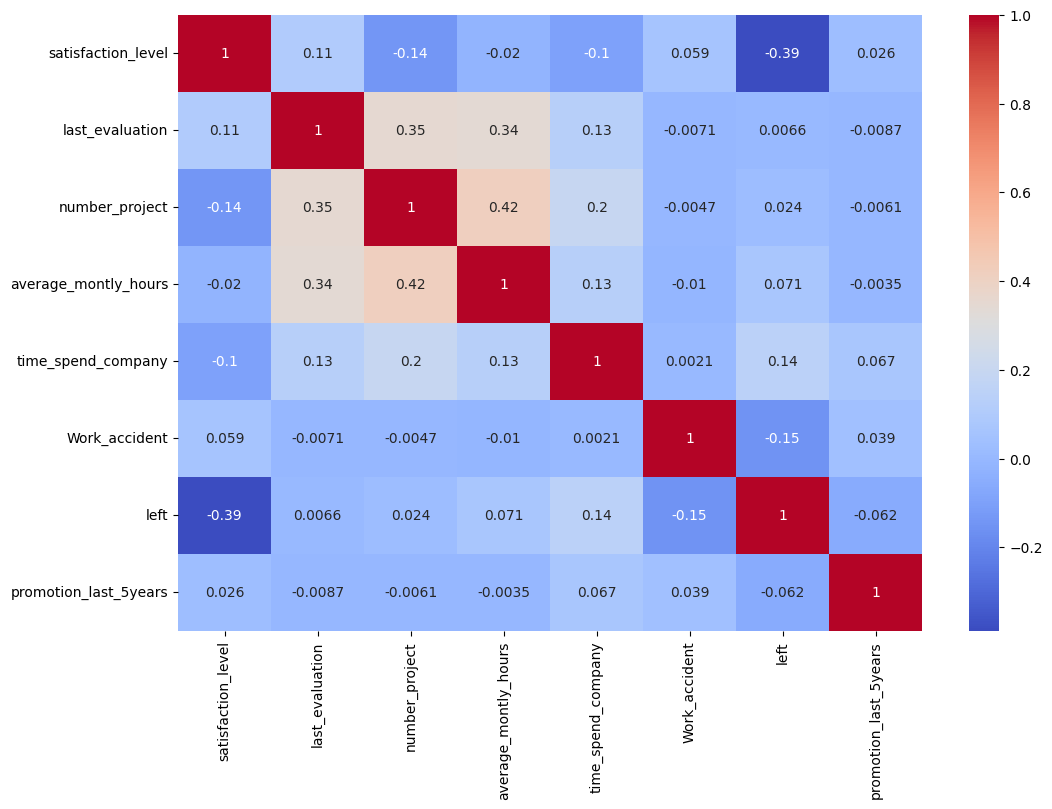

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.show()


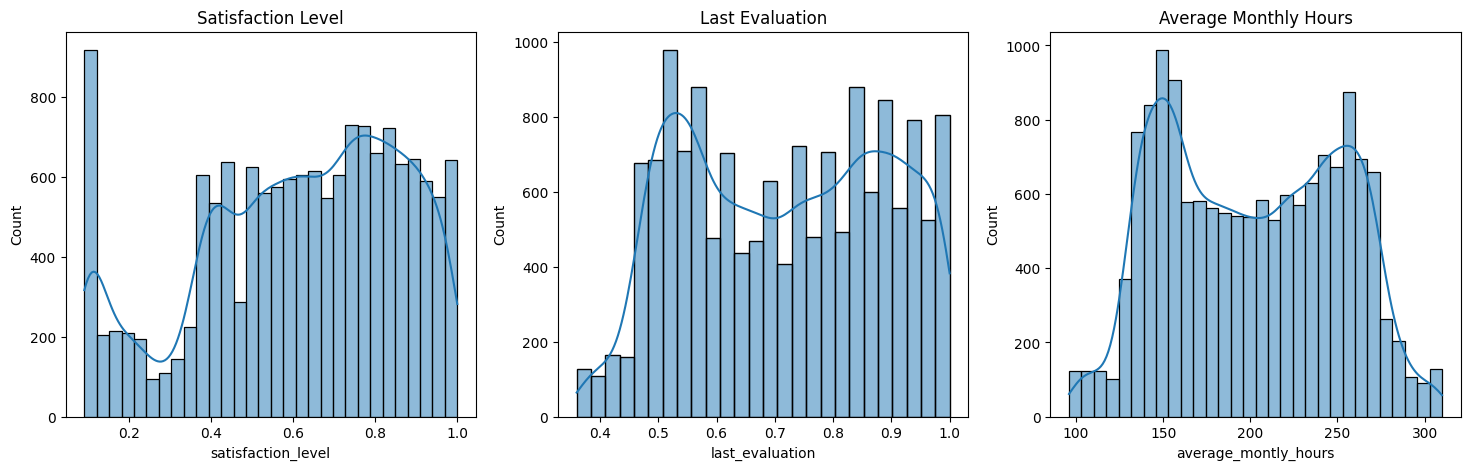

In [76]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0])
axes[0].set_title("Satisfaction Level")

sns.histplot(df['last_evaluation'], kde=True, ax=axes[1])
axes[1].set_title("Last Evaluation")

sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2])
axes[2].set_title("Average Monthly Hours")

plt.show()

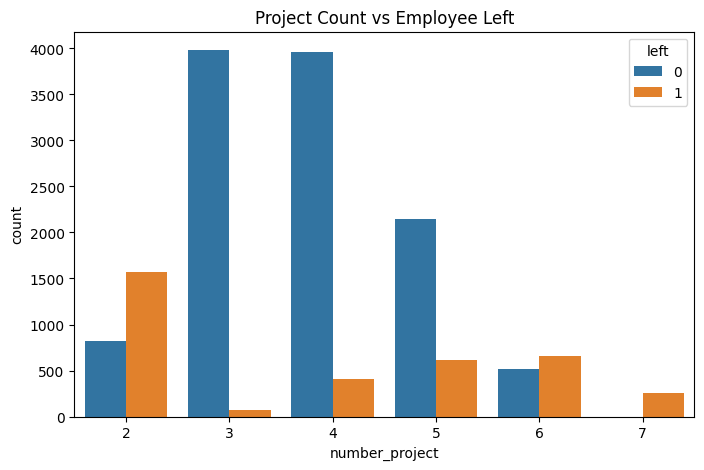

In [77]:
plt.figure(figsize=(8,5))
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Project Count vs Employee Left")
plt.show()

In [78]:
from sklearn.cluster import KMeans
features = ['satisfaction_level', 'last_evaluation',  'left']
X = df[features]
model = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_KMeans = model.fit_predict(X)
df['cluster'] = model.fit_predict(X)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,cluster
0,0.38,0.53,2,157,3,0,1,0,sales,low,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,2
4,0.37,0.52,2,159,3,0,1,0,sales,low,1


       satisfaction_level  last_evaluation
0                    0.38             0.53
1                    0.80             0.86
2                    0.11             0.88
3                    0.72             0.87
4                    0.37             0.52
...                   ...              ...
14994                0.40             0.57
14995                0.37             0.48
14996                0.37             0.53
14997                0.11             0.96
14998                0.37             0.52

[3571 rows x 2 columns]


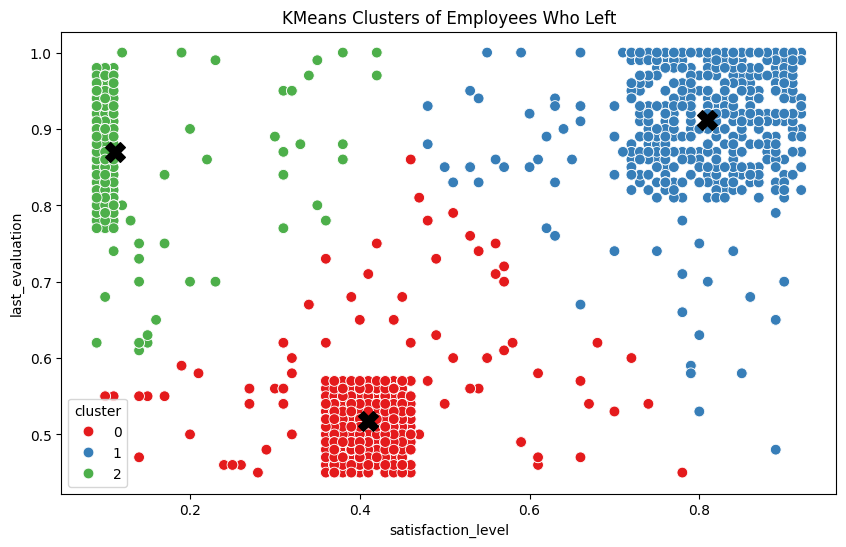

In [79]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Filter employees who left
left_emp = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]
print(left_emp)
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
left_emp['cluster'] = kmeans.fit_predict(left_emp)

# Plot clusters
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    palette='Set1',
    data=left_emp,
    s=60
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("KMeans Clusters of Employees Who Left")
plt.show()

In [80]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,cluster
0,0.38,0.53,2,157,3,0,1,0,sales,low,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,2
4,0.37,0.52,2,159,3,0,1,0,sales,low,1


In [81]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df.drop('left', axis = 1)
y = df['left']
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude = 'object').columns
X_Cat = pd.get_dummies(X[cat_cols], drop_first = True)
X_final = pd.concat([X[num_cols], X_Cat], axis =1 )
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size = 0.2,  random_state = 42, stratify = y )

print("Before SMOTE:")
print(y_train.value_counts())


sm = SMOTE(random_state = 42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_sm.value_counts())





Before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64
After SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64


In [82]:
import sys, subprocess

print("Python used by notebook:")
print(sys.executable)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "imbalanced-learn"
])

Python used by notebook:
c:\Users\Atharv Bansal\Desktop\IITG Projects\venv\Scripts\python.exe


0

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns 

In [84]:
log_reg = LogisticRegression(max_iter = 1000, random_state = 42)
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state= 42)
y_train_pred_lr = cross_val_predict(log_reg, X_train_sm, y_train_sm,cv=cv)
print("Logistic Regression Classification Report:")
print(classification_report(y_train_sm, y_train_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9142
           1       1.00      1.00      1.00      9142

    accuracy                           1.00     18284
   macro avg       1.00      1.00      1.00     18284
weighted avg       1.00      1.00      1.00     18284



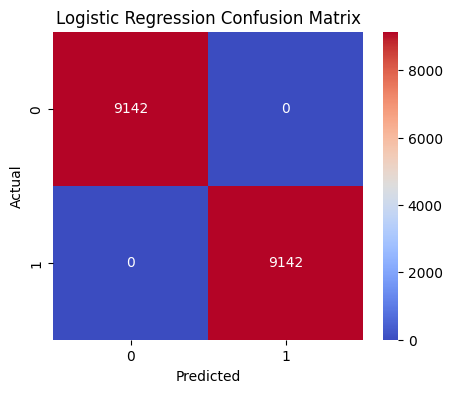

In [85]:
cm_lr = confusion_matrix(y_train_sm, y_train_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='coolwarm')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression ROC-AUC: 0.9999999999999999


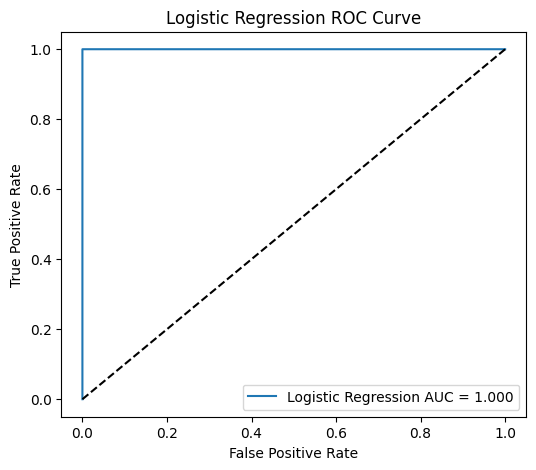

    Threshold  FPR  TPR/Recall
0         inf  0.0    0.000000
1         1.0  0.0    0.000109
2         1.0  0.0    0.000219
3         1.0  0.0    0.000438
4         1.0  0.0    0.001094
5         1.0  0.0    0.001313
6         1.0  0.0    0.001641
7         1.0  0.0    0.001860
8         1.0  0.0    0.004813
9         1.0  0.0    0.005032
10        1.0  0.0    0.006891
11        1.0  0.0    0.007219
12        1.0  0.0    0.007548
13        1.0  0.0    0.007766
14        1.0  0.0    0.008095
15        1.0  0.0    0.008313
16        1.0  0.0    0.009626
17        1.0  0.0    0.009845
18        1.0  0.0    0.011704
19        1.0  0.0    0.011923


In [ ]:
# Probability predictions using CV
y_train_prob_lr = cross_val_predict(
    log_reg,
    X_train_sm,
    y_train_sm,
    cv=cv,
    method='predict_proba'
)[:, 1]

auc_lr = roc_auc_score(y_train_sm, y_train_prob_lr)
print("Logistic Regression ROC-AUC:", auc_lr)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train_sm, y_train_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {auc_lr:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()
import pandas as pd

threshold_df = pd.DataFrame({
    'Threshold': thresholds_lr,
    'FPR': fpr_lr,
    'TPR/Recall': tpr_lr
})

print(threshold_df.head(20))

In [ ]:
log_reg.fit(X_train_sm, y_train_sm)

y_test_pred_lr = log_reg.predict(X_test)
y_test_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred_lr))
print(confusion_matrix(y_test, y_test_pred_lr))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob_lr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2286
           1       1.00      1.00      1.00       714

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

[[2286    0]
 [   0  714]]
Test ROC-AUC: 1.0


In [ ]:
y_test
_prob_lr = cross_val_predict(
    log_reg,
    X_train_sm,
    y_train_sm,
    cv=cv,
    method='predict_proba'
)[:, 1]

auc_lr = roc_auc_score(y_train_sm, y_train_prob_lr)
print("Logistic Regression ROC-AUC:", auc_lr)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train_sm, y_train_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {auc_lr:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()
import pandas as pd

threshold_df = pd.DataFrame({
    'Threshold': thresholds_lr,
    'FPR': fpr_lr,
    'TPR/Recall': tpr_lr
})

print(threshold_df.head(20))